# Prepare

In [1]:
import os, yaml, random, uproot
import numpy as np
import awkward as ak
from coffea.nanoevents import NanoEventsFactory, BaseSchema
import scipy as sp
import scipy.stats as sps


import matplotlib as mpl
import matplotlib.pyplot as plt
import mplhep as hep
import boost_histogram as bh

#os.chdir('postprocess/fit')

In [2]:
year = 'Run2'

tagger_cut = {
    'low': {
        'SR1': 0.7,
        'SR2': 0.9,
    },
    'high': {
        'SR1': 0.9,
        'SR2': 2,
    }
}

In [3]:
base = 'output/Run2/signal'
#for yml in os.listdir(base):
    if not yml.endswith('.yaml'):
        continue
    mass, SR = yml.split('.')[0].split('_')[-2:]
    with open(os.path.join(base, yml), 'r', encoding='utf-8') as f:
        stats = yaml.safe_load(f)

    datacard = f'postprocess/fit/datacard/Run2/datacard_{mass}_{SR}.txt'
    with open(datacard, 'r', encoding='utf-8') as f:
        content = f.read()
    content = content.replace('pdfindex', f'pdfindex_{SR}')

    with open(datacard, 'w', encoding='utf-8') as f:
        f.write(content)

FileNotFoundError: [Errno 2] No such file or directory: 'postprocess/fit/output/Run2/signal'

In [4]:
filepath = {
    year: {
        r'$Z^\mathrm{\prime}(1TeV)\to H(bb)\gamma$': f'input/{year}/mc_signal_Hbb_1000.root',
        r'$Z^\mathrm{\prime}(2TeV)\to H(bb)\gamma$': f'input/{year}/mc_signal_Hbb_2000.root',
        r'$Z^\mathrm{\prime}(3TeV)\to H(bb)\gamma$': f'input/{year}/mc_signal_Hbb_3000.root',
        'data': f'input/{year}/data_Hbb.root',
    } for year in ['Run2']
}

SIG_COLOR = {
    r'$Z^\mathrm{\prime}(1TeV)\to H(bb)\gamma$': 'red',
    r'$Z^\mathrm{\prime}(2TeV)\to H(bb)\gamma$': 'red',
    r'$Z^\mathrm{\prime}(3TeV)\to H(bb)\gamma$': 'red',
}

events = {
    year: {
        k: NanoEventsFactory.from_root({filepath[year][k]: 'Events'}, schemaclass=BaseSchema, delayed=False).events() for k in filepath[year]
    } for year in filepath
}

# Fit

In [5]:
use_helvet = False ## true: use helvetica for plots, make sure the system have the font installed
if use_helvet:
    CMShelvet = hep.style.CMS
    CMShelvet['font.sans-serif'] = ['Helvetica', 'Arial']
    plt.style.use(CMShelvet)
else:
    plt.style.use(hep.style.CMS)

def flow(hist: bh.Histogram, overflow: bool=True, underflow: bool=False):
    h, var = hist.view(flow=(overflow | underflow)).value, hist.view(flow=(overflow | underflow)).variance
    if overflow: # h, var also include underflow bins but in plots usually no underflow data
        # And we've filled None with -999, so we shouldn't show underflow data (mostly from filled None)
        h[-2] += h[-1]; var[-2] += var[-1]
    if underflow:
        h[1] += h[0]; var[1] += var[0]
    if overflow or underflow:
        h, var = h[1:-1], var[1:-1]
    return np.abs(h), var

def error_bar(h, var, mode='data'):
    from scipy.interpolate import CubicSpline
    
    h, var = np.array(h), np.array(var)
    if mode == 'data':
        number = h
    elif mode == 'mc':  # h = k*N, var = k^2*N, std = k*sqrt(N)
        number = np.nan_to_num(h**2/var, nan=0)
    else:
        raise ValueError("mode should be 'data' or 'mc'! ")
    center = range(11)
    up = np.array([1.84, 3.30, 4.64, 5.92, 7.16, 8.38, 9.58, 10.77, 11.95, 13.11, 14.27]) - center
    down = center - np.array([0, 0.17, 0.71, 1.37, 2.09, 2.84, 3.62, 4.42, 5.23, 6.06, 6.89])
    cs_up = CubicSpline(x=center, y=up)
    cs_down = CubicSpline(x=center, y=down)
    
    Garwood = (number>=0) & (number<=10)
    poison_error_bar = np.sqrt(number)
    up_error_bar = np.copy(poison_error_bar)
    down_error_bar = np.copy(poison_error_bar)
    up_error_bar[Garwood] = cs_up(number[Garwood])
    down_error_bar[Garwood] = cs_down(number[Garwood])
    
    if mode == 'mc':
        up_error_bar *= np.nan_to_num(var/h, nan=1)
        down_error_bar *= np.nan_to_num(var/h, nan=1)

    return np.array([down_error_bar, up_error_bar])

## signal

In [ ]:
def crystal_ball(x, x0, sigmaL, sigmaR, alphaL, alphaR, nL, nR):
    nL, nR = np.abs(nL), np.abs(nR)
    AL = (nL/np.abs(alphaL))**nL * np.exp(-np.abs(alphaL)**2 / 2)
    AR = (nR/np.abs(alphaR))**nR * np.exp(-np.abs(alphaR)**2 / 2)
    BL = nL/np.abs(alphaL) - np.abs(alphaL)
    BR = nR/np.abs(alphaR) - np.abs(alphaR)

    range1 = (x-x0)/sigmaL < -alphaL
    range2 = ((x-x0)/sigmaL >= -alphaL) & ((x-x0)/sigmaL < 0)
    range3 = ((x-x0)/sigmaR >= 0) & ((x-x0)/sigmaR <= alphaR)
    range4 = (x-x0)/sigmaR > alphaR

    y = np.copy(x)
    y[range1] = AL * (BL + np.abs(x[range1]-x0)/sigmaL)**(-nL)
    y[range2] = np.exp(- ((x[range2]-x0)/sigmaL)**2 / 2)
    y[range3] = np.exp(- ((x[range3]-x0)/sigmaR)**2 / 2)
    y[range4] = AR * (BR + np.abs(x[range4]-x0)/sigmaR)**(-nR)

    pdf = y/np.sum(y)
    return pdf


def signal_fit(arrays, weight, plot_name: str, x_name: str, cuts=None, year='2018', bins=None, x_min: float=0, x_max: float=2000, bin_width=None, function=None, parameters=None):
    LUMI = {"2016pre": 19.52, "2016post": 16.81, "2017": 41.48, "2018": 59.83,}
    LUMI['Run2'] = np.sum(list(LUMI.values()))
    if cuts:
        arrays = {k: v[cuts[k]] for k, v in arrays.items()}
    if bins is None:
        bins = (x_max - x_min)//bin_width
    if bin_width is None:
        bin_width = (x_max - x_min)/bins


    ## canvas initializing
    # f, ax = plt.subplots()
    f = plt.figure(figsize=(9, 9))
    gs = mpl.gridspec.GridSpec(3, 1, height_ratios=[5, 1, 1], hspace=0.1)
    ax, ax1, ax2 = f.add_subplot(gs[0]), f.add_subplot(gs[1]), f.add_subplot(gs[2])
    ax.grid(); ax1.grid(); ax2.grid()
    hep.cms.label(data=True, year=year, ax=ax, lumi=LUMI[year], fontsize=18, llabel='Preliminary')


    ## analyze
    individual = {'h': {}, 'var': {}}
    
    x_axis = bh.axis.Regular(bins, x_min, x_max)
    hist = bh.Histogram(x_axis, storage=bh.storage.Weight())
    x_data = x_axis.centers
    
    for (k,v) in arrays.items():
        values = ak.fill_none(v, -999)
        
        if k!='data' and weight is not None:
            hist.fill(values, weight=weight[k]*len(weight[k])/np.sum(weight[k]))
        else:
            hist.fill(values)
        h, var = flow(hist=hist, overflow=False, underflow=False)

        individual['h'][k] = h
        individual['var'][k] = var


    ## plot
    ax1.plot([x_min,x_max], [1,1], color='black', linestyle='dashed')
    ax2.plot([x_min,x_max], [0,0], color='black', linestyle='dashed')
    # or you can specify color='blue' in the above function to cover colorlist (you could comment out colorlist too)
    for (k, h) in individual['h'].items():
        err = error_bar(h, individual['var'][k], mode='mc')
        hep.histplot(h, bins=x_axis.edges, yerr=err, label=k, histtype='errorbar', stack=False, ax=ax, color='black')
        
        fit = function(x_data, **parameters) * np.sum(h)
        ratio = h/fit
        ratio_err = np.mean(err, axis=0)/fit
        #flag = np.where(h > fit, np.zeros_like(h, dtype=np.int32), np.ones_like(h, dtype=np.int32))
        pull = (h-fit)/np.mean(err, axis=0)
        chi2 = np.sum((h-fit)[h>0] **2 / h[h>0])

        ax.plot(x_data, fit, label='fit', linestyle='--', color=SIG_COLOR[k], linewidth=3)
        hep.histplot(ratio, yerr=ratio_err, bins=x_axis.edges, label=k, histtype='errorbar', stack=False, ax=ax1, color='black')
        hep.histplot(pull, bins=x_axis.edges, label=k, histtype='fill', stack=False, ax=ax2, color=SIG_COLOR[k])


    ## axises
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0, 1.2*ax.get_ylim()[1])
    ax.set_xticklabels([])

    # ax.ticklabel_format(useOffset=False, style='scientific')
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.tick_params(axis='x', which='major', labelsize=0)
    ax.set_ylabel('A.U.', fontsize=20, ha='right', y=1)

    # ratio panel
    ax1.set_xlim(x_min, x_max)
    ax1.set_ylim(0, 2)
    ax1.tick_params(axis='both', which='major', labelsize=16)
    ax1.tick_params(axis='x', which='major', labelsize=0)
    ax1.set_ylabel(r'$\frac{MC}{Fit}$', fontsize=20, ha='center', y=0.5)

    ax2.set_xlim(x_min, x_max)
    ymax = np.max([3, np.max(np.abs(ax2.get_ylim()))])
    ax2.set_ylim(-ymax, +ymax)
    ax2.set_yticks(ticks=range(int(-ymax), int(ymax+1), int(2*ymax//4)))
    if x_min == 720:
        ax2.set_xticks(ticks=[720]+list(range(x_max, x_min, -100))[::-1])
    ax2.tick_params(axis='both', which='major', labelsize=16)
    ax2.set_xlabel(x_name, fontsize=22, ha='right', x=1)
    ax2.set_ylabel(r'$\frac{MC - Fit}{MC\ unc.}$', fontsize=20, ha='center', y=0.5)


    ## title, text and legend
    # plt.title('ROC Curve of HWW4q vs. QCD', fontsize=24,color="black")
    ax.legend(loc="best", ncol=1, frameon=False, fontsize=18)
    ax.text(0.98*ax.get_xlim()[1]+0.02*ax.get_xlim()[0], ax.get_ylim()[1]*0.6, r"$\frac{\chi^2}{NDF}=%.2f$"%(chi2/(bins-1-7)), fontsize=21, color="black", ha='right')
    # r"$\frac{\chi^2}{NDF}=\frac{%.2f}{%d-1-%d}=%.2f$"%(chi2, bins, 7, chi2/(bins-1-7))
    ## finalizing
    if not os.path.exists(f'../plots/fit/{year}'):
        os.makedirs(f'../plots/fit/{year}')
    plt.savefig(f"../plots/fit/{year}/{plot_name}.pdf", bbox_inches='tight')
    plt.show()

In [ ]:
y = year
for SR in ['SR1', 'SR2']:
    SR_cut=f"""((events[y][k].mass_Higgs > 110) & (events[y][k].mass_Higgs < 140) & (events[y][k].tagger_Hbb > {tagger_cut['low'][SR]}) &  (events[y][k].tagger_Hbb < {tagger_cut['high'][SR]}))"""


    with open(f'output/{y}/signal/fit_info_signal_1000_{SR}.yaml', 'r', encoding='utf-8') as f:
        fit_info = yaml.safe_load(f)
    arrays={k: events[y][k].mass_Zprime[eval(SR_cut)] for k in events[y] if k in SIG_COLOR and '1' in k}
    _weight = {k: events[y][k].weight[eval(SR_cut)] for k in arrays}
    signal_fit(arrays=arrays, weight=_weight, x_name=r'$m_{H\gamma}$', plot_name=f'{SR}_m_Zp=1TeV', bin_width=3, x_min=720, x_max=1300, year=y, function=crystal_ball, 
            parameters={k: v for k, v in fit_info.items() if k != 'event_sum'})

    with open(f'output/{y}/signal/fit_info_signal_2000_{SR}.yaml', 'r', encoding='utf-8') as f:
        fit_info = yaml.safe_load(f)
    arrays={k: events[y][k].mass_Zprime[eval(SR_cut)] for k in events[y] if k in SIG_COLOR and '2' in k}
    _weight = {k: events[y][k].weight[eval(SR_cut)] for k in arrays}
    signal_fit(arrays=arrays, weight=_weight, x_name=r'$m_{H\gamma}$', plot_name=f'{SR}_m_Zp=2TeV', bin_width=5, x_min=1600, x_max=2400, year=y, function=crystal_ball, 
            parameters={k: v for k, v in fit_info.items() if k != 'event_sum'})

    with open(f'output/{y}/signal/fit_info_signal_3000_{SR}.yaml', 'r', encoding='utf-8') as f:
        fit_info = yaml.safe_load(f)
    arrays={k: events[y][k].mass_Zprime[eval(SR_cut)] for k in events[y] if k in SIG_COLOR and '3' in k}
    _weight = {k: events[y][k].weight[eval(SR_cut)] for k in arrays}
    signal_fit(arrays=arrays, weight=_weight, x_name=r'$m_{H\gamma}$', plot_name=f'{SR}_m_Zp=3TeV', bin_width=5, x_min=2400, x_max=3600, year=y, function=crystal_ball, 
            parameters={k: v for k, v in fit_info.items() if k != 'event_sum'})

## background

In [6]:
def dijet2(x, p1, p2):
    y = np.power(x, p1 + p2*np.log(x))
    pdf = y / np.sum(y)
    return pdf

def dijet3(x, p1, p2, p3):
    y = np.power(x, p1 + p2*np.log(x) + p3*(np.log(x))*(np.log(x)))
    pdf = y / np.sum(y)
    return pdf

def expow1(x, p1):
    y = np.power(x, p1)
    pdf = y / np.sum(y)
    return pdf

def expow2(x, p1, p2):
    y = np.power(x, p1) * np.exp(p2*x)
    pdf = y / np.sum(y)
    return pdf

def invpow2(x, p1, p2):
    y = np.power(1+p1*x, p2)
    pdf = y / np.sum(y)
    return pdf

def invpow3(x, p1, p2, p3):
    y = np.power(1+p1*x, p2+p3*x)
    pdf = y / np.sum(y)
    return pdf

def background_fit(arrays, weight, plot_name: str, x_name: str, year='2018', bins=None, x_min: float=0, x_max: float=2000, bin_width=None, fit_info=None):
    LUMI = {"2016pre": 19.52, "2016post": 16.81, "2017": 41.48, "2018": 59.83,}
    LUMI['Run2'] = np.sum(list(LUMI.values()))
    if bins is None:
        bins = (x_max - x_min)//bin_width
    if bin_width is None:
        bin_width = (x_max - x_min)/bins


    ## canvas initializing
    # f, ax = plt.subplots()
    f = plt.figure(figsize=(9, 9))
    gs = mpl.gridspec.GridSpec(3, 1, height_ratios=[6, 1, 1], hspace=0.1)
    ax, ax1, ax2 = f.add_subplot(gs[0]), f.add_subplot(gs[1]), f.add_subplot(gs[2])
    ax.grid(); ax1.grid(); ax2.grid()
    hep.cms.label(data=True, year=year, ax=ax, lumi=LUMI[year], fontsize=18, llabel='Preliminary')


    ## analyze
    individual = {'h': {}, 'var': {}}
    
    x_axis = bh.axis.Regular(bins, x_min, x_max)
    hist = bh.Histogram(x_axis, storage=bh.storage.Weight())
    x_data = x_axis.centers

    for (k,v) in arrays.items():
        values = ak.fill_none(v, -999)

        if k!='data' and weight is not None:
            hist.fill(values, weight=weight[k]*len(weight[k])/np.sum(weight[k]))
        else:
            hist.fill(values)
        h, var = flow(hist=hist, overflow=False, underflow=False)

        individual['h'][k] = h
        individual['var'][k] = var


    ## plot
    COLOR = {'expow1': 'red', 'expow2': 'darkorange', 'invpow2': 'green', 'invpow3': 'Cyan', 'dijet3': 'purple', 'dijet2': 'blue'}
    ax1.plot([x_min,x_max], [1,1], color='black', linestyle='dashed')
    ax2.plot([x_min,x_max], [0,0], color='black', linestyle='dashed')
    # or you can specify color='blue' in the above function to cover colorlist (you could comment out colorlist too)
    for (k, h) in individual['h'].items():
        err = error_bar(h, individual['var'][k], mode='data')
        hep.histplot(h, bins=x_axis.edges, yerr=np.where(h>0, err, 0), label=k, histtype='errorbar', stack=False, ax=ax, color='black')

        for func in COLOR:
            fit = eval(func)(x_data, **{p: fit_info[p][func] for p in fit_info if p.startswith('p') and func in fit_info[p]})
            fit = fit * fit_info['norm'] / np.sum(fit[x_data>=650])
            ratio = h/fit
            ratio_err = np.mean(err, axis=0)/fit
            #flag = np.where(h > fit, np.zeros_like(h, dtype=np.int32), np.ones_like(h, dtype=np.int32))
            pull = (h-fit)/np.mean(err, axis=0)
            cut = (h>0)&(x_data>=650)
            chi2 = np.sum((h-fit)[cut]**2/h[cut])

            ax.plot(x_data, fit, label=func+', '+r"$\frac{\chi^2}{NDF}=%.3f$"%(chi2/(np.sum(cut)-1-2)), linestyle='--', linewidth=2, color=COLOR[func])
            hep.histplot(ratio, yerr=np.where(ratio>0, ratio_err, 0), bins=x_axis.edges, label=k, histtype='errorbar', stack=False, ax=ax1, color=COLOR[func])
            hep.histplot(pull, yerr=1, bins=x_axis.edges, label=k, histtype='errorbar', stack=False, ax=ax2, color=COLOR[func])


    ## axises
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(1e-1, 5e1*ax.get_ylim()[1])
    ax.set_yscale('log')
    ax.set_xticklabels([])

    # ax.ticklabel_format(useOffset=False, style='scientific')
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.tick_params(axis='x', which='major', labelsize=0)
    ax.set_ylabel('Events', fontsize=20, ha='right', y=1)

    # ratio panel
    ax1.set_xlim(x_min, x_max)
    ax1.set_ylim(0, 2)
    ax1.tick_params(axis='both', which='major', labelsize=16)
    ax1.tick_params(axis='x', which='major', labelsize=0)
    ax1.set_ylabel(r'$\frac{data}{Fit}$', fontsize=20, ha='center', y=0.5)

    ax2.set_xlim(x_min, x_max)
    #ymax = np.max([3, np.max(np.abs(ax2.get_ylim()))])
    ax2.set_ylim(-3, +3)
    ax2.set_yticks(ticks=range(int(-3), int(3+1), 2))
    #if x_min == 720:
    #    ax2.set_xticks(ticks=[720]+list(range(900, x_max+1, 300)))
    ax2.tick_params(axis='both', which='major', labelsize=16)
    ax2.set_xlabel(x_name, fontsize=22, ha='right', x=1)
    ax2.set_ylabel(r'$\frac{data - Fit}{data\ unc.}$', fontsize=20, ha='center', y=0.5)


    ## title, text and legend
    # plt.title('ROC Curve of HWW4q vs. QCD', fontsize=24,color="black")
    ax.legend(loc="best", ncol=2, frameon=False, fontsize=16)

    ## finalizing
    plot_dir = f'../plots/fit/{year}'
    if not os.path.exists(plot_dir):
        os.makedirs(plot_dir)
    plt.savefig(f'{plot_dir}/{plot_name}.pdf', bbox_inches='tight')
    plt.show()

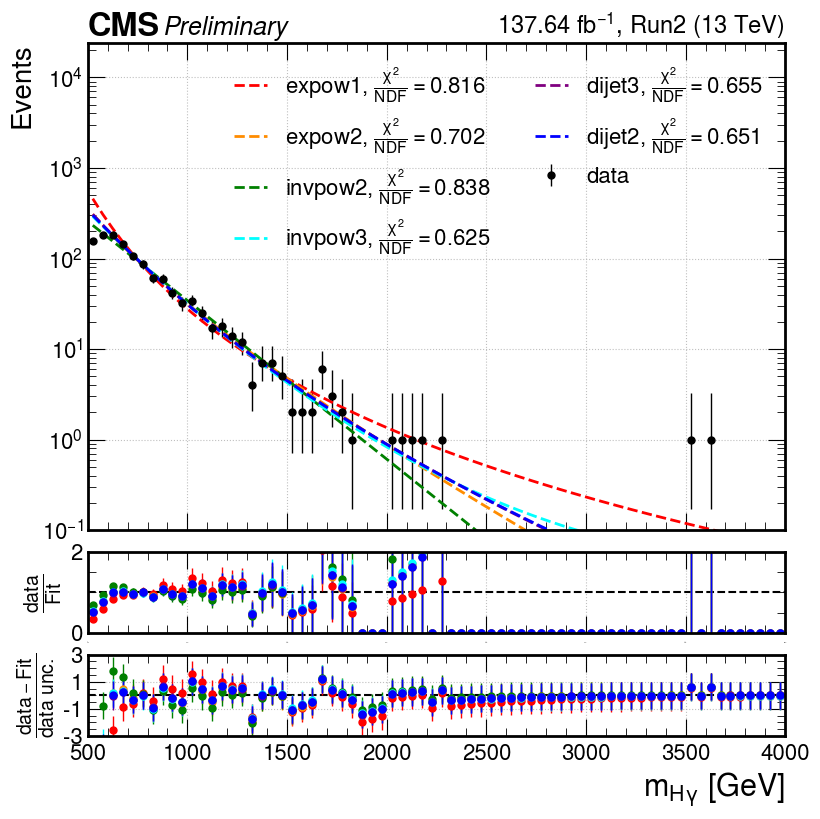

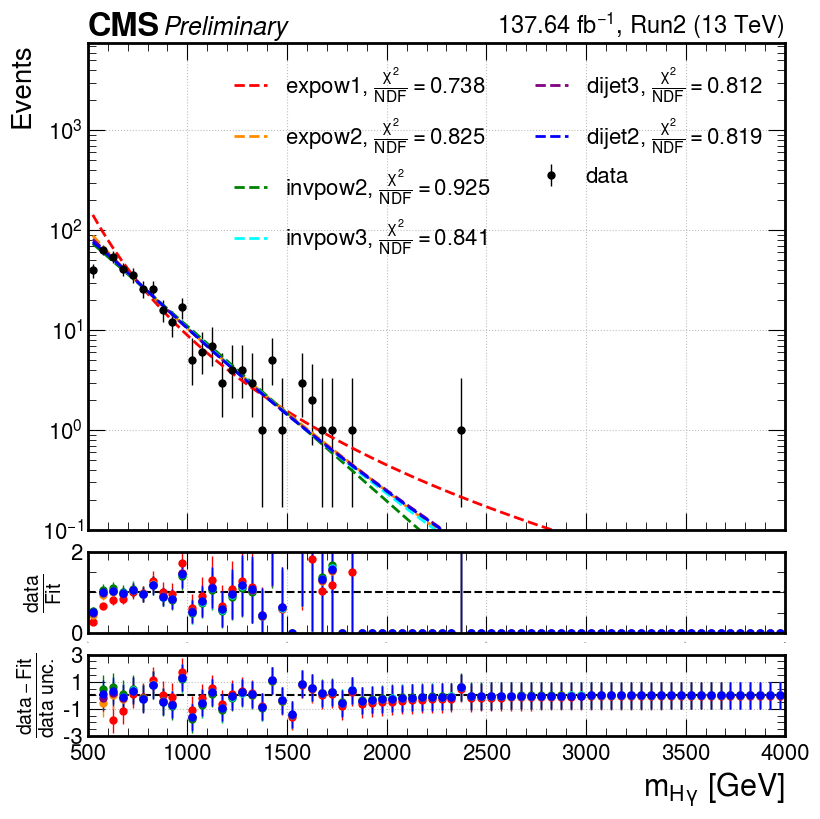

In [7]:
y = year

for SR in ('SR1', 'SR2'):
    CR_cut=f"""(
    (
        ((events[y][k].mass_Higgs > 50) & (events[y][k].mass_Higgs < 70)) |
        ((events[y][k].mass_Higgs > 100) & (events[y][k].mass_Higgs < 110)) |
        ((events[y][k].mass_Higgs > 145))
    ) & (events[y][k].tagger_Hbb > {tagger_cut['low'][SR]}) &  (events[y][k].tagger_Hbb < {tagger_cut['high'][SR]}))"""

    with open(f'output/{y}/background/fit_info_background_{SR}.yaml', 'r', encoding='utf-8') as f:
        fit_info = yaml.safe_load(f)
    #del fit_info['event_sum']
    arrays = {k: events[y][k].mass_Zprime[eval(CR_cut)] for k in events[y] if k == 'data'}
    _weight = {k: events[y][k].weight[eval(CR_cut)] for k in arrays}
    background_fit(arrays=arrays, weight=_weight, x_name=r'$m_{H\gamma}$ [GeV]', plot_name=f"background_fit_{SR.replace('S', 'C')}", bins=70, x_min=500, x_max=4000, year=y,
        fit_info=fit_info)

# Bias study

In [ ]:
with open('bias_pull.yaml', 'r', encoding='utf-8') as f:
    result = yaml.safe_load(f)

pull, error = result['mean'], result['sigma']

In [ ]:
def magic_pull(pull):
    y = pull * np.exp(-np.abs(pull))+(-0.5+np.random.rand(*np.shape(pull)))*0.05
    return y

def magic_sigma(sigma):
    yerr = sigma * np.exp(-3*np.abs(sigma))
    _yerr = np.copy(yerr)+0.1
    too_small = (yerr < 0.01)
    yerr[too_small] = _yerr[too_small]
    return yerr

def plot_pull(SR):
    f = plt.figure(figsize=(9, 9))
    gs = mpl.gridspec.GridSpec(1, 1, hspace=0.08)
    ax = f.add_subplot(gs[0])
    ax.grid()
    hep.cms.label(data=False, year='Run2', ax=ax, fontsize=18, llabel='Simulation')
    
    COLOR = {'dijet2': 'blue', 'dijet3': 'purple', 'expow1': 'red', 'expow2': 'darkorange', 'invpow2': 'green', 'invpow3': 'hotpink'}
    for func in pull:
        y = magic_pull(list(pull[func][SR].values()))
        yerr = magic_sigma(list(error[func][SR].values()))
        if func in ('expow2', 'invpow3') :
            print(SR)
            print(y)
            print(yerr)
            if SR=='SR2':
                y=np.copy(y)
        ax.errorbar(x=list(pull[func][SR].keys()), y=y, yerr=yerr, label=func, marker='o', color=COLOR[func], markersize=5, capsize=3, ls='none')
    ax.plot([500, 4000], [0.5, 0.5], color='grey', linestyle='dashed')
    ax.plot([500, 4000], [-0.5, -0.5], color='grey', linestyle='dashed')
    ax.set_xlim(500, 4000)
    ax.set_ylim(-1, 1)
    ax.set_xlabel('signal mass', fontsize=20, ha='right', x=1)
    ax.set_ylabel('Pull Mean', fontsize=20, ha='right', y=1)
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.legend(loc="best", ncol=3, frameon=False, fontsize=18)

    plt.savefig(f"../plots/fit/Run2/bias_study_{SR}.pdf", bbox_inches='tight')
    plt.show()

In [ ]:
plot_pull(SR='SR1')
plot_pull(SR='SR2')

# F test

In [ ]:
toy_stat = {}
for generate_model in ['dijet2', 'expow1', 'invpow2']:
    higher_model = generate_model[:-1] + str(int(generate_model[-1])+1)
    
    a = uproot.open(f"higgsCombine.{generate_model}.GoodnessOfFit.mH120.123456.root")
    toy_stat[generate_model] = a['limit']['limit'].array()
    
    b = uproot.open(f"higgsCombine.{higher_model}.GoodnessOfFit.mH120.123456.root")
    toy_stat[higher_model] = b['limit']['limit'].array()

In [ ]:
def F_statistics(stat_lower_order, stat_high_order, n1, n2):
    numerator = (np.log(stat_lower_order) - np.log(stat_high_order)) / (n2 - n1)
    denominator = np.log(stat_lower_order)
    return numerator/denominator

In [ ]:
bins, x_min, x_max = 10, 0, 20
func = 'dijet2'
f = plt.figure(figsize=(9, 9))
gs = mpl.gridspec.GridSpec(1, 1, hspace=0.08)
ax = f.add_subplot(gs[0])
ax.grid()
hep.cms.label(data=False, year='Run2', ax=ax, fontsize=18, llabel='Simulation')

x_axis = bh.axis.Regular(bins, x_min, x_max)
hist = bh.Histogram(x_axis, storage=bh.storage.Weight())
hist.fill(sps.poisson.rvs(mu=2, loc=-2, size=1000)+sps.expon.rvs(scale=3,size=1000))
h, err = hist.view().value, np.sqrt(hist.view().variance)
hep.histplot(h, bins=x_axis.edges, yerr=err, label='dijet2 vs. dijet3', histtype='step', stack=False, ax=ax, color='blue')
ax.plot([17.6, 17.6], [0, 1e3], color='black', linestyle='dashed', label='pseudo-data, p=0.01')
ax.set_xlim(0, x_max)
ax.set_ylim(0, np.max(h)*1.3)
ax.set_xlabel('F test statistics', fontsize=20, ha='right', x=1)
ax.set_ylabel('Number of toys', fontsize=20, ha='right', y=1)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.legend(loc="best", ncol=1, frameon=False, fontsize=18)

plt.savefig(f"../plots/fit/Run2/Ftest_{func}.pdf", bbox_inches='tight')
plt.show()

In [ ]:
bins, x_min, x_max = 10, 0, 20
func = 'expow2'
f = plt.figure(figsize=(9, 9))
gs = mpl.gridspec.GridSpec(1, 1, hspace=0.08)
ax = f.add_subplot(gs[0])
ax.grid()
hep.cms.label(data=False, year='Run2', ax=ax, fontsize=18, llabel='Simulation')

x_axis = bh.axis.Regular(bins, x_min, x_max)
hist = bh.Histogram(x_axis, storage=bh.storage.Weight())
hist.fill(sps.poisson.rvs(mu=4, size=1000)+sps.expon.rvs(scale=2,size=1000))
h, err = hist.view().value, np.sqrt(hist.view().variance)
hep.histplot(h, bins=x_axis.edges, yerr=err, label='expow1 vs. expow2', histtype='step', stack=False, ax=ax, color='darkorange')
ax.plot([14.6, 14.6], [0, 1e3], color='black', linestyle='dashed', label='pseudo-data, p=0.03')
ax.set_xlim(0, x_max)
ax.set_ylim(0, np.max(h)*1.3)
ax.set_xlabel('F test statistics', fontsize=20, ha='right', x=1)
ax.set_ylabel('Number of toys', fontsize=20, ha='right', y=1)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.legend(loc="best", ncol=1, frameon=False, fontsize=18)

plt.savefig(f"../plots/fit/Run2/Ftest_{func}.pdf", bbox_inches='tight')
plt.show()

In [ ]:
bins, x_min, x_max = 10, 0, 24
func = 'invpow2'
f = plt.figure(figsize=(9, 9))
gs = mpl.gridspec.GridSpec(1, 1, hspace=0.08)
ax = f.add_subplot(gs[0])
ax.grid()
hep.cms.label(data=False, year='Run2', ax=ax, fontsize=18, llabel='Simulation')

x_axis = bh.axis.Regular(bins, x_min, x_max)
hist = bh.Histogram(x_axis, storage=bh.storage.Weight())
hist.fill(sps.poisson.rvs(loc=-4, mu=4, size=1000)+sps.expon.rvs(scale=5,size=1000))
h, err = hist.view().value, np.sqrt(hist.view().variance)
hep.histplot(h, bins=x_axis.edges, yerr=err, label='invpow2 vs. invpow3', histtype='step', stack=False, ax=ax, color='green')
ax.plot([14.6, 14.6], [0, 1e3], color='black', linestyle='dashed', label='pseudo-data, p=0.11')
ax.set_xlim(0, x_max)
ax.set_ylim(0, np.max(h)*1.3)
ax.set_xlabel('F test statistics', fontsize=20, ha='right', x=1)
ax.set_ylabel('Number of toys', fontsize=20, ha='right', y=1)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.legend(loc="best", ncol=1, frameon=False, fontsize=18)

plt.savefig(f"../plots/fit/Run2/Ftest_{func}.pdf", bbox_inches='tight')
plt.show()

# Signal injection

In [ ]:
a=uproot.open('higgsCombine.1600.MultiDimFit.mH120.123456.root')

In [ ]:
signal_strength = {}
signal_strength_err = {}
for f in os.listdir('.'):
    if '.root' not in f:
        continue
    mass = int(f.split('.')[1])
    a = uproot.open(f)
    r = a['limit']['r'].array()
    signal_strength[mass] = np.mean(r) 
    signal_strength_err[mass] = np.std(r)

In [ ]:
signal_strength

In [ ]:
def plot_pull(r, r_err, plot_name: str, x_name: str, x_min=500, x_max=4000,):

    ## canvas initializing
    f = plt.figure(figsize=(9, 9))
    gs = mpl.gridspec.GridSpec(2, 1, height_ratios=[2, 1], hspace=0.08)
    ax, ax1 = f.add_subplot(gs[0]), f.add_subplot(gs[1])
    ax.grid(); ax1.grid()
    hep.cms.label(data=False, year='Run2', ax=ax, fontsize=18, llabel='Simulation')
        
    ## plot
    mass = list(r.keys())
    signal_strength = np.array(list(r.values()))
    signal_strength_err = np.array(list(r_err.values()))
    ax.errorbar(x=mass, y=signal_strength, yerr=signal_strength_err, linestyle='')
    ax.scatter(x=mass, y=signal_strength, label=r'Fit on toys with $r_{truth}=1$ injection', s=50)
    ax.plot([x_min,x_max], [1, 1], color='gray', linestyle='dashed')
    ax1.plot([x_min,x_max], [0, 0], color='black', linestyle='solid')
    ax1.plot([x_min,x_max], [0.5, 0.5], color='gray', linestyle='dashed')
    ax1.plot([x_min,x_max], [-0.5, -0.5], color='gray', linestyle='dashed')
    ax1.fill_between([x_min,x_max], [0.5, 0.5], [-0.5, -0.5], color='Gainsboro')
    ax1.scatter(x=mass, y=(signal_strength-1)/signal_strength_err, s=50, label='Pull')
    
    ## axises
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.tick_params(axis='x', which='major', labelsize=0)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0.2, 1.8)
    ax.set_ylabel(r'$\hat{r}_{fit}$', ha='right', fontsize=24, y=1)

    ax1.tick_params(axis='both', which='major', labelsize=16)
    ax1.set_xlabel(x_name, fontsize=22, ha='right', x=1)
    ax1.set_xlim(x_min, x_max)
    ax1.set_ylim(-1, 1)
    ax1.set_ylabel(r'$(\hat{r}_{fit}-r_{truth})/\sigma_{fit}$', ha='right', fontsize=20, y=1)

    ## title, text and legend
    ax.legend(loc="best", ncol=1, frameon=False, fontsize=18)
    ax1.legend(loc="best", ncol=1, frameon=False, fontsize=18)

    ## finalizing
    if not os.path.exists('../plots'):
        os.makedirs('../plots')
    plt.savefig(f"../plots/{plot_name}.pdf", bbox_inches='tight')
    plt.show()

In [ ]:
plot_pull(signal_strength, signal_strength_err, x_name=r'$m(Z^\prime)$ [GeV]', plot_name='signal_injection')

# Cross-section upper limits

In [ ]:
MASS = [700, 800, 900, 1000, 1200, 1400, 1600, 1800, 2000, 2200, 2400, 2600, 3000, 3500]

rate_limit = {m: {'SR1': {}, 'SR2': {}, 'combine':{}} for m in MASS} 

for f in os.listdir('./'):
    if not (f.endswith('.root') and f.startswith('higgsCombinef.')):
        continue
    mass, SR = f.split('.')[1].split('_')
    stats = uproot.open(f)
    limits = stats['limit']['limit'].array()
    rate_limit[int(mass)][SR] = {
        'Expected -2sigma': float(limits[0]),
        'Expected -1sigma': float(limits[1]),
        'Expected Limit': float(limits[2]),
        'Expected +1sigma': float(limits[3]),
        'Expected +2sigma': float(limits[4]),
    }
    
with open('./rate_limit.yaml', 'w', encoding='utf-8') as f:
    yaml.dump(rate_limit, f)
    

with open('../../src/parameters/cross-section.yaml', 'r', encoding='utf-8') as f:
    cross_section_nominal = yaml.safe_load(f)['ZpToHG']

# convert pb to fb
cross_section_nominal = {int(k.split('_M')[1]): v*1e3/2 for k, v in cross_section_nominal.items()}

    
cross_section_limit = {
    SR: {
        m : {
            limit: rate_limit[m][SR][limit] * cross_section_nominal[m] for limit in rate_limit[m][SR]
        } for m in MASS
    } for SR in ['SR1', 'SR2', 'combine']
}
cross_section_limit['SR1'][700]['Expected Limit'], cross_section_limit['SR2'][700]['Expected Limit']

## plot

In [ ]:
from scipy.interpolate import CubicSpline

def plot_cross_section_limit(cross_section_limit, x_name: str, SR: str, cuts=None, year='2018', x_min=500, x_max=3800):
    LUMI = {"2016pre": 19.52, "2016post": 16.81, "2017": 41.48, "2018": 59.83,}
    LUMI["Run2"] = np.sum(list(LUMI.values()))
    if cuts:
        arrays = {k: v[cuts[k]] for k, v in arrays.items()}

    ## canvas initializing
    # colorlist=['red', 'blue', 'green', 'black', 'cyan', 'darkorange', 'darkviolet', 'SlateGray', 'HotPink', 'LightSkyBlue']
    # mpl.rcParams['axes.prop_cycle'] = cycler(color=colorlist)
    f = plt.figure(figsize=(9, 9))
    ax = plt.gca()
    plt.grid()
    hep.cms.label(data=False, ax=ax, fontsize=18, year=year, lumi=LUMI[year])
    
    x = np.arange(700, 3501, 10)
        
    ## plot
    plt.fill_between(x,
        CubicSpline(MASS, [cross_section_limit[m]['Expected +2sigma'] for m in MASS])(x),
        CubicSpline(MASS, [cross_section_limit[m]['Expected -2sigma'] for m in MASS])(x),
        color='#85D1FBff', label='Expected limit 95% CL'
    )
    plt.fill_between(x, 
        CubicSpline(MASS, [cross_section_limit[m]['Expected +1sigma'] for m in MASS])(x),
        CubicSpline(MASS, [cross_section_limit[m]['Expected -1sigma'] for m in MASS])(x),
        color='#FFDF7Fff', label='Expected limit 68% CL'
    )
    plt.plot(x, CubicSpline(MASS, [cross_section_limit[m]['Expected Limit'] for m in MASS])(x), color='DimGray', label='Expected limit', linestyle='dashed')

    ## axises
    ax.set_xlabel(x_name, fontsize=22, ha='right', x=1)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(1e-2, ax.get_ylim()[1]*5)
    ax.set_yscale('log')
    #ax.ticklabel_format(useOffset=False, style='scientific')
    ax.tick_params(axis='both', which='major', labelsize=16)
    #x_major_locator=plt.MultipleLocator(bin_width*8 if variable=='fj_gen_mass' else bin_width*2)
    #y_major_locator=MultipleLocator(1)
    #ax.xaxis.set_major_locator(x_major_locator)
    #ax.yaxis.set_major_locator(y_major_locator)
    ax.set_ylabel('95% CL upper limit on '+r'$\sigma[Z^\mathrm{\prime}\to H\gamma]$ (fb)', fontsize=20, ha='right', y=1)

    plt.xticks(size=16)
    plt.yticks(size=16)

    ## title, text and legend
    # plt.title('ROC Curve of HWW4q vs. QCD', fontsize=24,color="black")
    ax.legend(loc="best", ncol=1, frameon=False, fontsize=22)
    # plt.text(0.96*ax.get_xlim()[1], ax.get_ylim()[1]*0.72,"At "+r"$\mathrm{m^{gen}_{H}=}$"+f"{Higgsmass} GeV", fontsize=24, color="black", ha='right')

    ## finalizing
    if not os.path.exists(f'../plots/fit/{year}'):
        os.makedirs(f'../plots/fit/{year}')
    plt.savefig(f"../plots/fit/{year}/{SR}_limit.pdf", bbox_inches='tight')
    plt.show()

In [ ]:
for SR in ('SR1', 'SR2', 'combine'):
    plot_cross_section_limit(cross_section_limit=cross_section_limit[SR], x_name='Resonance mass (GeV)', year='Run2', SR=SR)